In [29]:
# 1. 데이터 불러오기
# 2. 데이터 전처리
# 3. 데이터셋 나누기
# 4. 배치준비(Dataloder -> 개수 잘라서 gpu에 넣어 좀 더 효율적으로 학습)
# 5. 배치 후 확인

In [30]:
import torch
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms # 전처리하거나 변환할때 쓰는 모듈

In [31]:
# 사용자 정의 dataset
# 내가 가진 데이터 구조에 맞춰서 직접 Dataset클래스 정의하겠다.(customize)

In [32]:
class hi_set(Dataset):
    def __init__(self, length=10, transform=None):
        torch.manual_seed(101)  # 항상 똑같은 랜덤데이터 나오도록 고정
        self.x=10*torch.ones(length,2) # 10으로 채워진 10,2 크기 텐서
        self.y=torch.ones(length,1) # 1로 채워진 10, 1 크기 텐서
        self.transform=transform

    def __getitem__(self, idx):
        sample_data=self.x[idx], self.y[idx] # idx에 해당하는 x,y를 묶음 -> 데이터 1개 반환
        if self.transform:
            sample_data=self.transform(sample_data)
        return sample_data

    def __len__(self):
        return self.len

In [33]:
def scaling(sample):
    x,y=sample # x,y=(10,1)
    return x/10. , y/10.

In [34]:
data1=hi_set(10, transform=scaling)
print(data1[0])

(tensor([1., 1.]), tensor([0.1000]))


In [35]:
# 데이터를 꺼낼때마다 다르게 변형이 가능(원본은 훼손하지 않으면서)

In [36]:
class addr:
    def __init__(self, add1=1):
        self.add1=add1

    def __call__(self, sample):
        x,y=sample # 튜플 언패킹
        x=x+self.add1
        y=y+self.add1
        sample=x+y
        return sample

In [39]:
a1=addr() # __init__(selft.add1=1)
data1=hi_set(10, transform=a1) # __init__ 호출되면서 self.transform=a1
data1[-1] # hi_set.__getitem__[-1] 로 x,y 값 가져옴

tensor([13., 13.])

In [38]:
# 1. a1=addr() 로 객체 생성
# 2. data[-1] => __getitem__ 호출됨

# __getitem__ 안에 transform => a1 객체가 있으므로 if문이 true가 됨

# __call__ 메소드 수행됨
# (10+1) + (1+1) =13

In [40]:
# Compose : 데이터가 들어오면 변환도구들을 순서대로 꺼내서 실행함
data_transform=transforms.Compose([scaling, a1])

In [41]:
data1=hi_set(3, transform=data_transform) # self.x, self.y 3행
next(iter(data1)) #hi_set의 data1.__getitem__[0] 호출 => transform이 [scaling, a1] 순차적으로 실행

# 원본 [10.,10.] [1.]
# scaling [1., 1.] [0.1]
# a1 x: [1., 1.]+1=[2., 2.]
#    y: 0.1+1=1.1
# x+y

tensor([3.1000, 3.1000])

In [42]:
from torchvision import datasets
import torchvision.transforms as transforms

In [43]:
# CenterCrop : 원본이 28*28 인데, 정중앙 20*20 영역만 남기겠다.
# ToTensor : 데이터를 0~1 사이로 압축하면서 텐서로 변환
crop_trans=transforms.Compose([transforms.CenterCrop(20),
                               transforms.ToTensor()])

In [45]:
train_data=datasets.MNIST(
    # 데이터의 저장공간
    root='data',
    #학습용 데이터
    train=True,
    download=True,
    # 데이터 꺼낼때 자동으로 transform 적용
    transform=crop_trans
)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data\MNIST\raw\t10k-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting data\MNIST\raw\t10k-labels-idx1-ubyte.gz to data\MNIST\raw



In [59]:
test_data=datasets.MNIST(
    #데이터의 저장공간
    root='data',
    train=False,
    download=True,
    transform=crop_trans
)

In [60]:
print(train_data[0]) # 데이터 첫번째 샘플-(이미지 텐서, 해당 이미지에 대한 정답)
print(train_data[0][0]) # 변환 끝낸 이미지 텐서
print(train_data[0][1]) # 이미지에 대한 정답

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0118, 0.0706, 0.0706, 0.0706, 0.4941, 0.5333, 0.6863, 0.1020,
          0.6510, 1.0000, 0.9686, 0.4980],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.1176, 0.1412, 0.3686, 0.6039,
          0.6667, 0.9922, 0.9922, 0.9922, 0.9922, 0.9922, 0.8824, 0.6745,
          0.9922, 0.9490, 0.7647, 0.2510],
         [0.0000, 0.0000, 0.0000, 0.1922, 0.9333, 0.9922, 0.9922, 0.9922,
          0.9922, 0.9922, 0.9922, 0.9922, 0.9922, 0.9843, 0.3647, 0.3216,
          0.3216, 0.2196, 0.1529, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0706, 0.8588, 0.9922, 0.9922, 0.9922,
          0.9922, 0.9922, 0.7765, 0.7137, 0.9686, 0.9451, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.

In [61]:
print(train_data[0][0].shape)
# __getitem__ 호출 -> transform 을 통해 데이터 전처리되 (CenterCrop, ToTensor)
# 데이터가 ToTensor 거치면서 차원이 재구성됨
# [Channel, Height, weight] => 흑백이미지라서 채널이 1개

torch.Size([1, 20, 20])


In [62]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [63]:
import matplotlib.pyplot as plt

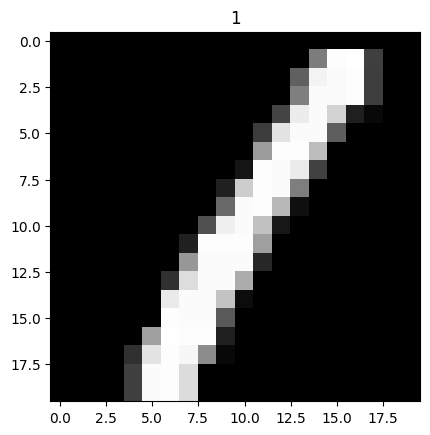

In [67]:
# 첫번째 샘플 이미지
# 파이토치에서는 [1, 20, 20] 3차원
# matplot에서는 [20, 20] 2차원
# imshow() : 수치데이터 -> 이미지 형태로 시각화
plt.imshow(train_data[0][0].view(20,20), cmap='gray')
plt.title(train_data[0][1])
plt.show()

# 원본 28*28 흑백
# 객체[인덱스] -> __getitem__ 호출되면서 -> transform(centercrop, totensor)
# -> 20*20 이미지(centercrop) -> totensor로 0~1사이로 변환

In [68]:
from torch.utils.data import DataLoader

# 64개로 잘라서 섞는다
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)


In [72]:
# 한 배치만 꺼냄
# next로 첫번째 배치 가져옴(feature, label) 튜플구조
train_features, train_labels = next(iter(train_loader))
# print(train_features)
# print(train_labels)
print(train_features.shape) # (batch_size, channels, height, width)
print(train_labels.shape) # 64장 이미지에 대응하는 0~9 사이의 정수 정답 (batch_size)

torch.Size([64, 1, 20, 20])
torch.Size([64])


In [ ]:
# train_features, train_labels = next(iter(train_loader))
# => 첫번째 덩어리(64개) 가져다줘

# __getitem__ 호출됨 -> 64개를 무작위로 골라 데이터를 하나씩 꺼낸다
# transform 호출됨 -> 꺼내진 각 64개 이미지에 대해 (CenterCrop, ToTensor 수행한다)

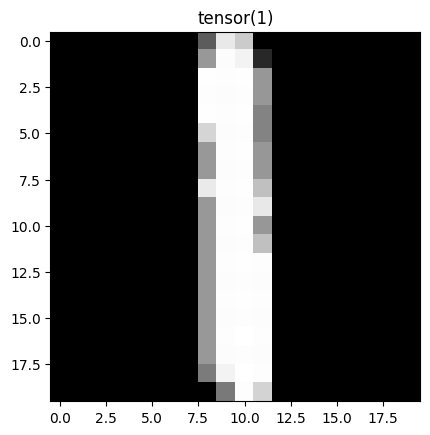

In [76]:
# 첫번째 이미지 텐서
# squeeze : 1차원 제거
f1 = train_features[0].squeeze()
l1 = train_labels[0] # 첫샘플의 정답
plt.imshow(f1, cmap="gray")
plt.title(l1)
plt.show()